# A tree example: what improves, and what is the objective?

Run the cells from top to bottom. All simulation and fitting code is visible here;
there is no `run_example` helper to inspect elsewhere.

We compare an independent cEBMF fit with a neural CGB loading hierarchy. We inspect
**prediction error**, **the loss optimized during prior learning**, and **the sampling
trace** separately. They answer different questions.

Select your `cebmf` kernel. If needed, first run `python -m pip install -e .` from the
package folder and restart the kernel. The joint sampler currently uses CPU.

In [1]:
from pathlib import Path
import json
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF

# One place to change the experiment.
QUICK = True
N, P = (300, 80) if QUICK else (1000, 200)
SEED = 1
SIGMA = 1.25
K = 10
BASELINE_ITERATIONS = 30
PRIOR_ROUNDS = 8 if QUICK else 15
BURNIN = 100 if QUICK else 200
DRAWS = 200 if QUICK else 400

OUTPUT_DIR = Path("output") / "tree_joint_walkthrough"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(1)
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
print(f"{N} samples, {P} features; outputs: {OUTPUT_DIR.resolve()}")

300 samples, 80 features; outputs: C:\Document\Serieux\Travail\python_work\package\cebmf_torch\output\tree_joint_walkthrough


## 1. Simulate four groups using seven additive programs

Every sample has the root program, one branch program, and one leaf program.
Each program has its own sparse, signed feature pattern. Noise SD is 1.25.

```
root
  left branch
    leaf 1: first 10% of samples
    leaf 2: next 20%
  right branch
    leaf 3: next 50%
    leaf 4: last 20%
```

The intervals below have no gaps, and the seven feature masks are generated separately.

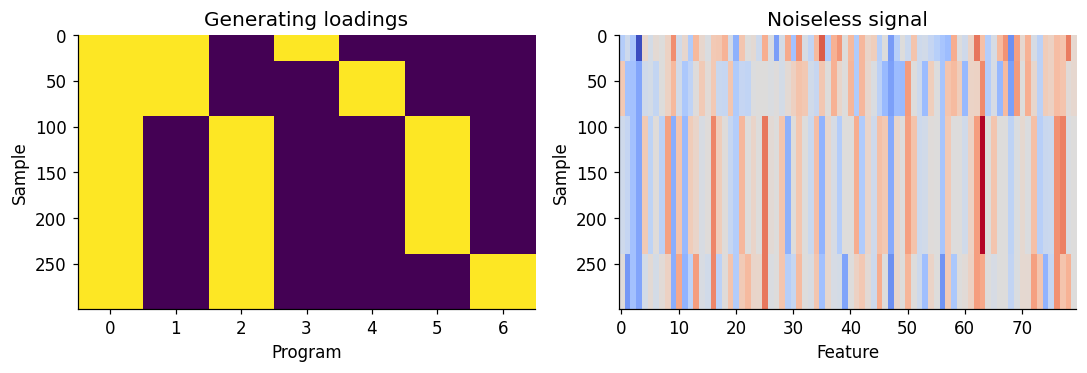

In [2]:
rng = torch.Generator().manual_seed(SEED)

feature_mask = torch.randint(0, 2, (P, 7), generator=rng).double()
F_true = feature_mask * torch.randn(P, 7, generator=rng, dtype=torch.float64)

L_true = torch.zeros(N, 7, dtype=torch.float64)
cut1, cut2, cut3 = int(0.1 * N), int(0.3 * N), int(0.8 * N)
L_true[:, 0] = 1                     # root
L_true[:cut2, 1] = 1                 # left branch
L_true[cut2:, 2] = 1                  # right branch
L_true[:cut1, 3] = 1                 # leaf 1
L_true[cut1:cut2, 4] = 1              # leaf 2
L_true[cut2:cut3, 5] = 1              # leaf 3
L_true[cut3:, 6] = 1                  # leaf 4

X_true = L_true @ F_true.T
Y = X_true + SIGMA * torch.randn(N, P, generator=rng, dtype=torch.float64)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].imshow(L_true.numpy(), aspect="auto", interpolation="nearest", cmap="viridis")
axes[0].set(title="Generating loadings", xlabel="Program", ylabel="Sample")
axes[1].imshow(X_true.numpy(), aspect="auto", interpolation="nearest", cmap="coolwarm", vmin=-4, vmax=4)
axes[1].set(title="Noiseless signal", xlabel="Feature", ylabel="Sample")
fig.tight_layout()
plt.show()

**Why this is not a uniquely recoverable seven-program tree.** The root column is
the sum of the branch columns, and each branch is the sum of its leaf columns.
There are only four distinct signal profiles, so the noiseless matrix has rank at most
four. A different set of four factors can reconstruct the same signal. Good prediction
therefore does not, by itself, demonstrate recovery of the original seven programs.

## 2. Hide measurements before fitting

We hold out 2% of noisy entries. Both methods see the same training matrix.
`X_true`, `L_true`, and `F_true` are used only for simulation and evaluation.

In [3]:
holdout_rng = torch.Generator().manual_seed(SEED + 400)
held_out = torch.rand(N, P, generator=holdout_rng) < 0.02
Y_train = Y.clone()
Y_train[held_out] = torch.nan

def rmse(prediction, target, mask=None):
    error = prediction - target
    if mask is not None:
        error = error[mask]
    return float(error.square().mean().sqrt())

print("Training entries:", int((~held_out).sum()))
print("Held-out entries:", int(held_out.sum()))
print("Rank of the generating loading matrix:", int(torch.linalg.matrix_rank(L_true)))

Training entries: 23537
Held-out entries: 463
Rank of the generating loading matrix: 4


## The learning algorithm, in cEBMF steps

The familiar structure is **form a residual → solve a normal-means problem → update the prior → repeat**.
Here the normal-means calculation proposes a loading at **fixed prior parameters**;
a correction includes the effect on its children. Prior learning happens between sampling rounds.

1. **Initialize** the factors using an independent fit. Fix the resulting rank, factor order,
   noise and feature prior; initialize the neural loading priors.
2. **Sample at fixed parameters.** Update all loading columns, then all feature columns.
   For each column, subtract the other factors to form its residual and compute normal-means
   statistics from the current sampled values. Propose a loading and mixture label from its
   own normal-means posterior, then accept/reject using the child-prior contributions.
   The independent feature prior in this example permits direct conditional draws.
3. **Learn the priors from joint draws.** After `sweeps_per_round` complete sweeps, keep the
   saved loading values, parents and labels together. Fit each neural prior to those latent
   draws using `steps` Adam steps; retain the best parameters on that same saved-draw loss.
   These are latent values, so no second measurement-error correction is applied.
4. **Repeat steps 2–3** for `PRIOR_ROUNDS`. Continue from the last sampled state.
5. **Freeze the priors**, discard `burnin` further sweeps, then retain `draws` samples,
   separated by `thin` sweeps.
6. **Predict** by averaging `L @ F.T` within retained draws: use `result.reconstruction`.

For a loading $v$, the proposal is proportional to its Gaussian likelihood times its own
conditional prior. If $D(v)$ is the sum of its children's log prior terms (holding child
values and mixture labels fixed), the acceptance probability is

$$\alpha=\min\{1,\exp[D(v_{\rm proposed})-D(v_{\rm current})]\}.$$

Without children, every proposal is accepted. `fit(T)` carries out learning and final
sampling; `iter_once()` performs only one sweep at fixed parameters. This is approximate
Monte Carlo EM, so a decreasing saved-draw prior loss does not guarantee improving
marginal likelihood or held-out RMSE. The code below shows the independent and joint fits
separately.


## 3. Fit the independent baseline long enough to inspect its progress

The baseline has independent Gaussian-mixture priors on L and F. It receives 30
variational iterations, compared with only five in the earlier quick diagnostic.
Its recorded optimization objective is the **negative ELBO**: lower is better for
this model. We also record prediction errors after each iteration, without using
them to select an iteration or tune the fit.

In [4]:
baseline = cEBMF(
    Y_train, K=K, prior_L="norm", prior_F="norm", S=SIGMA, device="cpu"
)
baseline.initialise_factors()

baseline_loss = []
baseline_signal_rmse = []
baseline_test_rmse = []
started = time.perf_counter()
for iteration in range(BASELINE_ITERATIONS):
    baseline.iter_once()
    prediction = baseline.L @ baseline.F.T
    baseline_loss.append(baseline.obj[-1])
    baseline_signal_rmse.append(rmse(prediction, X_true))
    baseline_test_rmse.append(rmse(prediction, Y, held_out))

baseline_prediction = baseline.L @ baseline.F.T
baseline_seconds = time.perf_counter() - started
print(f"Baseline: {baseline.model.K} retained factors, {baseline_seconds:.1f} seconds")

Baseline: 5 retained factors, 5.9 seconds


## 4. Fit the loading hierarchy through the usual cEBMF interface

For each loading, CGB learns a zero-spike probability with a neural network of the
earlier loadings. Its active component is a Gaussian with learned global mean and
variance. CGB is not a strictly binary or nonnegative loading prior.

`self_row_cov=True` selects joint sampling, including the child-prior contributions.
The feature prior stays independent: the feature patterns in this simulation are
unordered. `fit(PRIOR_ROUNDS)` performs prior-learning rounds and then collects
posterior draws. Rank, observation noise, feature priors and preprocessing stay fixed
after initialization. The initial fit can prune factors, so the retained rank may
differ from the baseline's.

In [5]:
model = cEBMF(
    Y_train,
    K=K,
    prior_L="cgb",
    prior_F="norm",
    self_row_cov=True,
    S=SIGMA,
    device="cpu",
    joint_kwargs={
        "initialization_iterations": 5 if QUICK else 10,
        "pretrain_steps": 50 if QUICK else 100,
        "sweeps_per_round": 10,
        "steps": 30,
        "burnin": BURNIN,
        "draws": DRAWS,
        "thin": 1 if QUICK else 2,
        "seed": SEED + 100,
        "progress_every": 50,
    },
)
model.initialise_factors()
started = time.perf_counter()
result = model.fit(PRIOR_ROUNDS)
joint_seconds = time.perf_counter() - started
posterior = result.joint_posterior
joint_prediction = result.reconstruction
print(f"Joint fit: {model.model.K} retained factors, {joint_seconds:.1f} seconds")

Joint sweep 50/300; kept 0 draws
Joint sweep 100/300; kept 0 draws
Joint sweep 150/300; kept 50 draws
Joint sweep 200/300; kept 100 draws
Joint sweep 250/300; kept 150 draws
Joint sweep 300/300; kept 200 draws
Joint fit: 8 retained factors, 39.6 seconds


## 5. What objective is being optimized?

The empirical-Bayes target is the observed-data marginal log likelihood:

$$\ell(\theta)=\log\sum_{Z,W}\int
p(Y_{\rm train}\mid L,F)\,p_\theta(L,Z)\,p_\psi(F,W)\,dL\,dF.$$

Here the sums/integrals include the appropriate discrete and continuous supports.
$Z$ and $W$ are component indicators. The feature-prior parameters $\psi$ and noise
are fixed during joint learning. For CGB,

$$p_\theta(L,Z)=\prod_{i,k}g_{\theta k}(L_{ik},Z_{ik}\mid L_{i,<k}),$$

where $g_{\theta k}$ is a zero atom with probability $1-\pi_k(L_{i,<k})$ and a
Gaussian slab with probability $\pi_k(L_{i,<k})$.

**The current solver does not compute $\ell(\theta)$.** It now reports an explicit approximate-posterior ELBO separately. Prior learning uses an
approximate Monte Carlo EM procedure. At round $t$, it collects $M$ joint latent
draws, holds those draws fixed, and reduces this negative complete-prior objective:

$$J_t(\theta)=-\frac{1}{MN}\sum_{m=1}^{M}\sum_{i,k}
\log g_{\theta k}\!\left(L_{ik}^{(m)},Z_{ik}^{(m)}\mid L_{i,<k}^{(m)}\right).$$

Likelihood and feature-prior terms are constant with respect to these parameters,
so they do not enter this parameter optimization. The code records $J_t$ before and
after each accepted parameter update. **Within a round, the same fixed-draw loss
cannot increase. Across rounds, the draws change, so the levels are not evaluations
of one fixed loss.** Finite-chain MCEM does not guarantee marginal-likelihood ascent.
The loss can be negative because continuous components contribute log densities.

In [6]:
# Each factor's record is already averaged over samples and latent draws.
# Summing the loading-factor records gives J_t as defined above.
loss_before, loss_after = [], []
for round_record in model.joint_sampler.learning_history:
    loading_records = round_record[0]  # axis 0 is L; F is not learned in this example
    loss_before.append(sum(item["before"] for item in loading_records))
    loss_after.append(sum(item["after"] for item in loading_records))

loss_before = np.asarray(loss_before)
loss_after = np.asarray(loss_after)
loss_decrease = loss_before - loss_after
assert np.all(loss_decrease >= -1e-10)

print("Round     Before       After     Accepted decrease")
for step, before, after in zip(range(1, PRIOR_ROUNDS + 1), loss_before, loss_after):
    print(f"{step:5d}  {before:10.4f}  {after:10.4f}  {before-after:17.4f}")

Round     Before       After     Accepted decrease
    1      0.5823      0.4674             0.1149
    2      0.4927      0.4336             0.0591
    3      0.4702      0.4334             0.0367
    4      0.4420      0.4064             0.0356
    5      0.3738      0.3477             0.0261
    6      0.3376      0.3152             0.0223
    7      0.3033      0.2827             0.0206
    8      0.3126      0.2898             0.0228


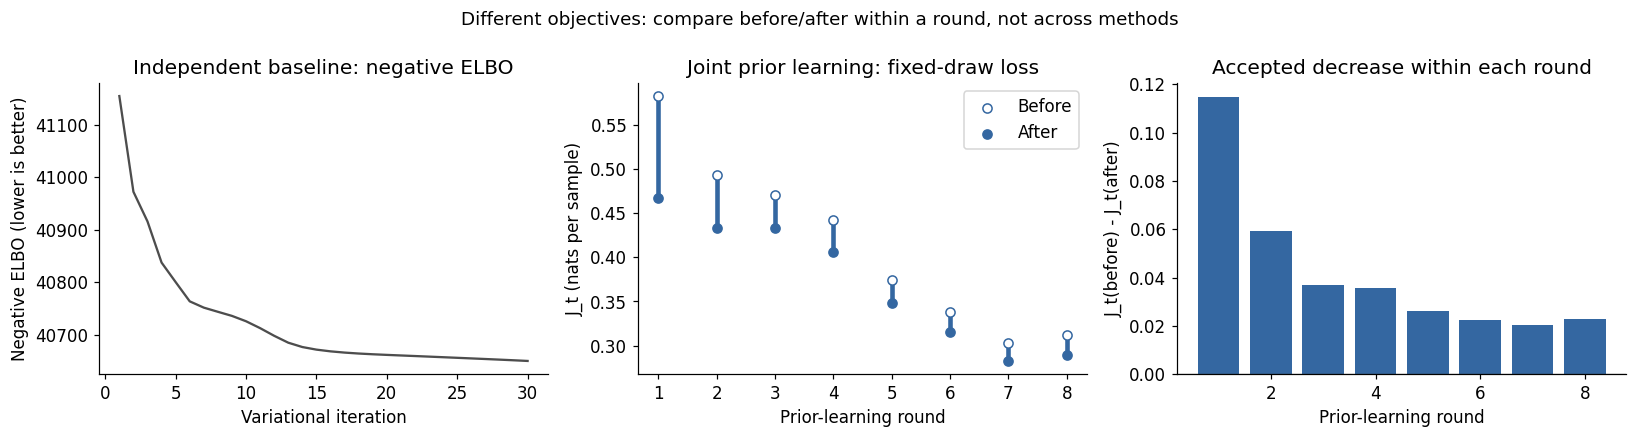

In [7]:
rounds = np.arange(1, PRIOR_ROUNDS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(np.arange(1, BASELINE_ITERATIONS + 1), baseline_loss, color="0.3")
axes[0].set(title="Independent baseline: negative ELBO", xlabel="Variational iteration", ylabel="Negative ELBO (lower is better)")

# Only connect before/after values WITHIN each round, where draws are identical.
axes[1].vlines(rounds, loss_after, loss_before, color="#3467a1", linewidth=3)
axes[1].scatter(rounds, loss_before, facecolors="white", edgecolors="#3467a1", label="Before", zorder=3)
axes[1].scatter(rounds, loss_after, color="#3467a1", label="After", zorder=3)
axes[1].set(title="Joint prior learning: fixed-draw loss", xlabel="Prior-learning round", ylabel="J_t (nats per sample)")
axes[1].legend()

axes[2].bar(rounds, loss_decrease, color="#3467a1")
axes[2].axhline(0, color="0.3", linewidth=0.8)
axes[2].set(title="Accepted decrease within each round", xlabel="Prior-learning round", ylabel="J_t(before) - J_t(after)")

fig.suptitle("Different objectives: compare before/after within a round, not across methods", fontsize=12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "objectives.png", dpi=150, bbox_inches="tight")
plt.show()

## Approximate ELBO, including entropy

`result.history_obj` is now the **negative regularized Monte Carlo ELBO**: lower is better.
It is estimated for an explicit posterior approximation fitted to the joint draws.
The approximation retains exact spikes and continuous component densities; HMM columns
retain whole paths. Fresh draws from this approximation estimate `E_q[log p - log q]`.

This is a diagnostic for the joint sampler, not the loss directly optimized by its
Monte Carlo EM updates. It need not improve at every round. Error bars below show
plus/minus two Monte Carlo standard errors; they do not assess chain mixing or the
variational approximation's accuracy. The last point uses the final retained draws.
With `penalty=1`, the regularized and ordinary ELBO agree.


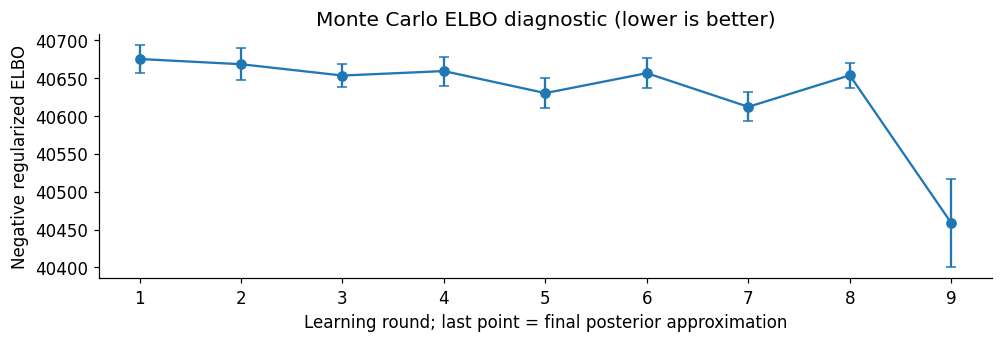

Final ELBO: -40458.67597146253
Final regularized ELBO: -40458.67597146253


In [8]:
estimates = result.history_elbo
losses = [estimate.loss for estimate in estimates]
errors = [2 * estimate.regularized_standard_error for estimate in estimates]
plt.figure(figsize=(9, 3), layout="constrained")
plt.errorbar(range(1, len(losses) + 1), losses, yerr=errors, marker="o", capsize=3)
plt.xlabel("Learning round; last point = final posterior approximation")
plt.ylabel("Negative regularized ELBO")
plt.title("Monte Carlo ELBO diagnostic (lower is better)")
plt.show()
print("Final ELBO:", result.elbo_estimate.elbo)
print("Final regularized ELBO:", result.elbo_estimate.regularized_elbo)


## 6. Compare prediction, rather than objective levels across methods

Signal RMSE compares predictions with the known noiseless simulation. Held-out RMSE
compares predictions with measurements that were excluded from fitting.

Even a perfect signal predictor has expected held-out **MSE** $\sigma^2$ under this
simulation. With $\sigma=1.25$, noise dominates the noisy prediction error. A substantial
relative improvement in latent-signal error can therefore produce a small improvement
in held-out RMSE. The finite held-out score may fall above or below 1.25 by chance.

In [9]:
baseline_signal = rmse(baseline_prediction, X_true)
joint_signal = rmse(joint_prediction, X_true)
baseline_test = rmse(baseline_prediction, Y, held_out)
joint_test = rmse(joint_prediction, Y, held_out)

print(f"{'Method':28s} {'Signal RMSE':>12s} {'Held-out RMSE':>15s}")
print(f"{'Independent, iteration 5':28s} {baseline_signal_rmse[4]:12.5f} {baseline_test_rmse[4]:15.5f}")
print(f"{'Independent, final iteration':28s} {baseline_signal:12.5f} {baseline_test:15.5f}")
print(f"{'Joint posterior mean':28s} {joint_signal:12.5f} {joint_test:15.5f}")
print(f"Signal RMSE reduction versus final baseline: {100*(1-joint_signal/baseline_signal):.2f}%")
print(f"Held-out RMSE reduction versus final baseline: {100*(1-joint_test/baseline_test):.2f}%")
print(f"Held-out signal RMSE (simulation truth only): baseline {rmse(baseline_prediction, X_true, held_out):.5f}; joint {rmse(joint_prediction, X_true, held_out):.5f}")
print("Held-out noisy prediction:", "improved in this run." if joint_test < baseline_test else "not improved in this run.")


Method                        Signal RMSE   Held-out RMSE
Independent, iteration 5          0.28166         1.26644
Independent, final iteration      0.24518         1.25390
Joint posterior mean              0.20568         1.25882
Signal RMSE reduction versus final baseline: 16.11%
Held-out RMSE reduction versus final baseline: -0.39%
Held-out signal RMSE (simulation truth only): baseline 0.22213; joint 0.18981
Held-out noisy prediction: not improved in this run.


## 7. Inspect posterior averaging and the sampling trace

During retained sampling, parameters are fixed. The log joint
$\log p(Y_{\rm train},L^{(m)},F^{(m)},Z^{(m)},W^{(m)}\mid\hat\theta,\hat\psi)$
should fluctuate; it is not an optimization curve. A visually stable trace is not a
convergence certificate.

The reconstruction is the mean of **products within draws**:
$\widehat X=M^{-1}\sum_m L^{(m)}F^{(m)\top}$. It is generally different from the
product of the marginal means. The following loop shows how prediction changes as
more retained draws are averaged. It uses one running matrix, avoiding a large
array of reconstructed matrices.

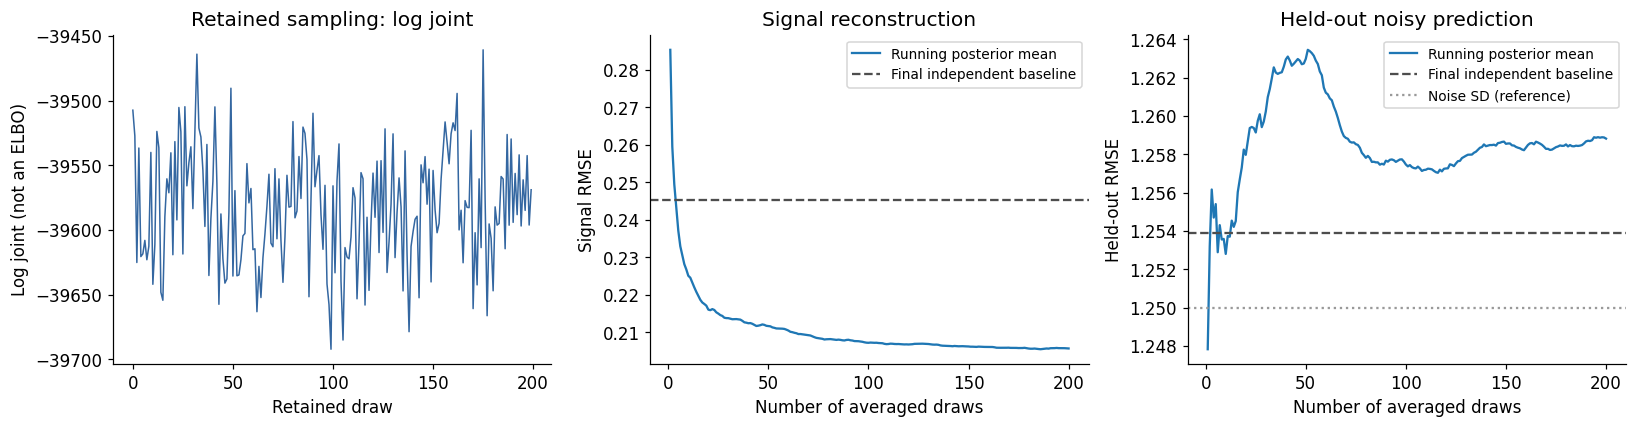

In [10]:
running_prediction = torch.zeros_like(Y)
running_signal_rmse, running_test_rmse = [], []
for count, (loading_draw, factor_draw) in enumerate(
    zip(posterior.loading_draws, posterior.factor_draws), start=1
):
    reconstructed_draw = loading_draw @ factor_draw.T
    running_prediction += (reconstructed_draw - running_prediction) / count
    running_signal_rmse.append(rmse(running_prediction, X_true))
    running_test_rmse.append(rmse(running_prediction, Y, held_out))

torch.testing.assert_close(running_prediction, joint_prediction)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(posterior.log_joint, color="#3467a1", linewidth=1)
axes[0].set(title="Retained sampling: log joint", xlabel="Retained draw", ylabel="Log joint (not an ELBO)")

axes[1].plot(np.arange(1, DRAWS + 1), running_signal_rmse, label="Running posterior mean")
axes[1].axhline(baseline_signal, color="0.3", linestyle="--", label="Final independent baseline")
axes[1].set(title="Signal reconstruction", xlabel="Number of averaged draws", ylabel="Signal RMSE")
axes[1].legend(fontsize=9)

axes[2].plot(np.arange(1, DRAWS + 1), running_test_rmse, label="Running posterior mean")
axes[2].axhline(baseline_test, color="0.3", linestyle="--", label="Final independent baseline")
axes[2].axhline(SIGMA, color="0.6", linestyle=":", label="Noise SD (reference)")
axes[2].set(title="Held-out noisy prediction", xlabel="Number of averaged draws", ylabel="Held-out RMSE")
axes[2].legend(fontsize=9)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sampling_and_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

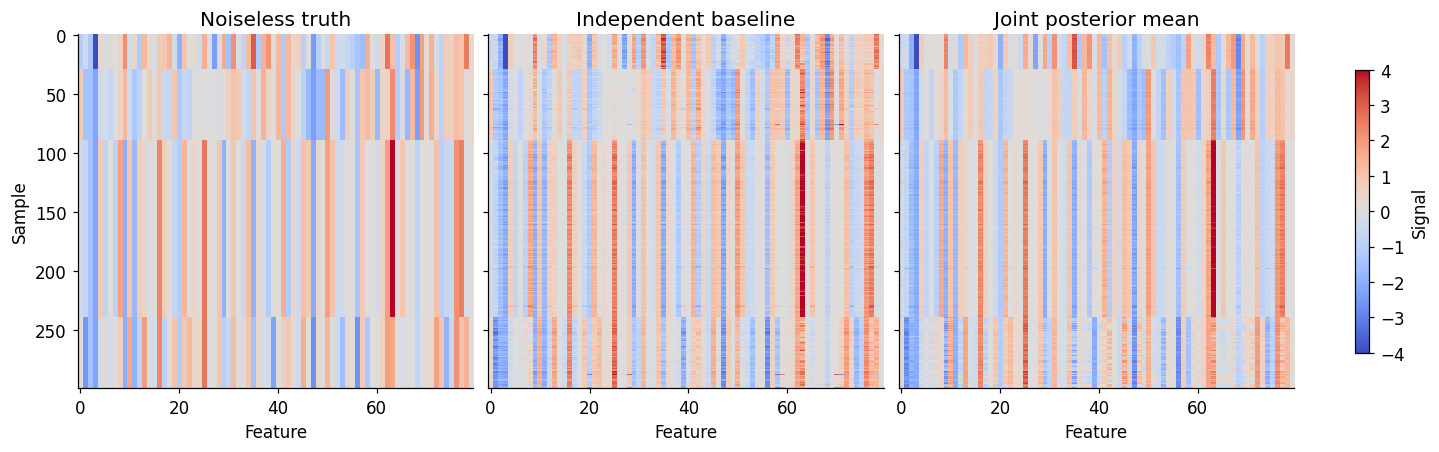

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True, layout="constrained")
for ax, value, title in zip(
    axes,
    (X_true, baseline_prediction, joint_prediction),
    ("Noiseless truth", "Independent baseline", "Joint posterior mean"),
):
    image = ax.imshow(value.numpy(), aspect="auto", interpolation="nearest", cmap="coolwarm", vmin=-4, vmax=4)
    ax.set(title=title, xlabel="Feature")
axes[0].set_ylabel("Sample")
fig.colorbar(image, ax=axes.tolist(), shrink=0.8, label="Signal")
fig.savefig(OUTPUT_DIR / "reconstructions.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. What can we conclude?

- **Is the baseline still changing?** Inspect its negative ELBO and compare its
  iteration-5 and final errors. Five iterations were a weak basis for comparison.
- **Are the prior updates doing their intended job?** Each paired before/after
  comparison should show a decrease in $J_t$. This does not prove that the observed-data
  likelihood or prediction improved.
- **Does posterior averaging look settled?** Look at the running prediction errors.
  More draws reduce Monte Carlo error only if the chain explores the relevant posterior;
  they cannot fix an inappropriate model or a poor fitted prior.
- **Is the gain useful?** Inspect held-out prediction and noiseless-signal error
  separately. If the gain remains small, report it as small. Adding a hierarchy need
  not improve this example: four profiles already form a simple low-rank signal.

This is one seed, with different prior families and potentially different retained
ranks. It does not isolate the benefit of conditional dependence. A stronger study
would match the prior family/rank/inference budget, use multiple simulation seeds and
multiple chains at the same fitted parameters, and evaluate genuinely held-out data.
No unique recovery of the generating seven-program tree is claimed.

For a single cell reproducing the fitted model on your own matrix, use the construction
in section 4 and keep `result.reconstruction` as the predicted signal. Fixed row side
information can be added with `X_l=...`. The current neural gates are used throughout.

In [12]:
# Save the numbers behind the figures, including unfavorable outcomes.
summary = {
    "config": {"n": N, "p": P, "seed": SEED, "sigma": SIGMA, "initial_k": K,
               "baseline_iterations": BASELINE_ITERATIONS, "prior_rounds": PRIOR_ROUNDS,
               "burnin": BURNIN, "draws": DRAWS},
    "retained_rank": {"baseline": baseline.model.K, "joint": model.model.K},
    "signal_rmse": {"baseline_iteration_5": baseline_signal_rmse[4],
                    "baseline_final": baseline_signal, "joint": joint_signal},
    "heldout_rmse": {"baseline_iteration_5": baseline_test_rmse[4],
                     "baseline_final": baseline_test, "joint": joint_test},
    "heldout_signal_rmse": {"baseline": rmse(baseline_prediction, X_true, held_out),
                            "joint": rmse(joint_prediction, X_true, held_out)},
    "seconds": {"baseline": baseline_seconds, "joint": joint_seconds},
    "baseline_negative_elbo": baseline_loss,
    "baseline_signal_rmse": baseline_signal_rmse,
    "baseline_heldout_rmse": baseline_test_rmse,
    "prior_loss_before": loss_before.tolist(),
    "prior_loss_after": loss_after.tolist(),
    "sampling_log_joint": posterior.log_joint,
    "running_signal_rmse": running_signal_rmse,
    "running_heldout_rmse": running_test_rmse,
}
(OUTPUT_DIR / "diagnostics.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("Saved figures and diagnostics to", OUTPUT_DIR.resolve())

Saved figures and diagnostics to C:\Document\Serieux\Travail\python_work\package\cebmf_torch\output\tree_joint_walkthrough
